# Data Visualization - Worked Example (WikiBio-mini)
*with Devin Kwok (2026)*

## Get Data

In [2]:
# download wikibio-mini dataset
import numpy as np

# *note:* the exclamation mark means run a *shell command*
# other useful tools for downloading and unpacking data: wget, curl, unzip, tar, huggingface_hub
!git clone https://github.com/devinkwok/wikibio-vis/

fatal: destination path 'wikibio-vis' already exists and is not an empty directory.


In [3]:
# load the CSV (column separated values) into a dataframe
# *note:* CSV is best for small datasets, other formats often work better (e.g. json, parquet, SQL database)
import pandas as pd             # a tabular data library (alternatives: polars, tidyverse)

df = pd.read_csv("wikibio-vis/wikibio-mini.csv")
df

,title,first_name,occupation,nationality,birth_year,age,article,url
0,james ruse,james,farmer,British,1760,77,james ruse ( 9 august 1759/17605 september 183...,https://en.wikipedia.org/wiki/index.php?curid=...
1,marguerite clark,marguerite,actor,American,1883,57,"marguerite clark ( february 22, 1883 -- septem...",https://en.wikipedia.org/wiki/index.php?curid=...
2,hugh millais,hugh,actor,British,1929,79,hugh geoffroy millais ( 23 december 1929 -- 4 ...,https://en.wikipedia.org/wiki/index.php?curid=...
3,antoni maria alcover i sureda,antoni,priest,Spanish,1862,69,"father antoni maria alcover i sureda, also kno...",https://en.wikipedia.org/wiki/index.php?curid=...
4,richard bentley ( publisher ),richard,publisher,British,1794,76,richard bentley ( 24 october 1794 -- 10 septem...,https://en.wikipedia.org/wiki/index.php?curid=...
...,...,...,...,...,...,...,...,...
5217,samuel cooke,samuel,lawyer,Australian,1847,82,samuel winter cooke ( 13 march 1847 -- 26 june...,https://en.wikipedia.org/wiki/index.php?curid=...
5218,doug ireland,doug,journalist,American,1946,67,"william douglas ireland ( march 31, 1946 -- oc...",https://en.wikipedia.org/wiki/index.php?curid=...
5219,werner heubeck,walter,manager,German,1923,85,"werner wolfgang heubeck, cbe ( 24 october 1923...",https://en.wikipedia.org/wiki/index.php?curid=...
5220,horace tozer,horace,lawyer,Australian,1844,72,sir horace tozer kcmg ( 23 april 1844 -- 20 au...,https://en.wikipedia.org/wiki/index.php?curid=...


## Exploratory Data Analysis

Nothing beats just __*looking at your data!*__

In [4]:
df.columns                      # what variables are there?

Index(['title', 'first_name', 'occupation', 'nationality', 'birth_year', 'age',
       'article', 'url'],
      dtype='str')

In [5]:
len(df)                         # how many rows are there?

5222

In [6]:
df.head()                       # look at the first few rows

,title,first_name,occupation,nationality,birth_year,age,article,url
0,james ruse,james,farmer,British,1760,77,james ruse ( 9 august 1759/17605 september 183...,https://en.wikipedia.org/wiki/index.php?curid=...
1,marguerite clark,marguerite,actor,American,1883,57,"marguerite clark ( february 22, 1883 -- septem...",https://en.wikipedia.org/wiki/index.php?curid=...
2,hugh millais,hugh,actor,British,1929,79,hugh geoffroy millais ( 23 december 1929 -- 4 ...,https://en.wikipedia.org/wiki/index.php?curid=...
3,antoni maria alcover i sureda,antoni,priest,Spanish,1862,69,"father antoni maria alcover i sureda, also kno...",https://en.wikipedia.org/wiki/index.php?curid=...
4,richard bentley ( publisher ),richard,publisher,British,1794,76,richard bentley ( 24 october 1794 -- 10 septem...,https://en.wikipedia.org/wiki/index.php?curid=...


In [7]:
# what do the articles look like?
articles = df["article"]        # get the `article`` column
articles.iloc[0]                # look at the article in the 0th row
# note: df.iloc[0] returns the entire first row

"james ruse ( 9 august 1759/17605 september 1837 ) was a cornish farmer who, at the age of 23, was convicted of breaking and entering and was sentenced to seven years ' transportation to australia. he arrived at sydney cove on the first fleet with 18 months of his sentence remaining. ruse applied to governor arthur phillip ( of the colony ) for a land grant, stating that he had been bred to farming. governor phillip, desperate to make the colony self-sufficient, allocated ruse an allotment at rose hill ( parramatta ), where he proved himself industrious and showed that it was possible for a family to survive through farming. having done this, ruse received a grant of, enabling him eventually to sell 600 bushels of corn. this was the very first grant of land in new south wales. ruse later exchanged the grant for more fertile land on the hawkesbury river. in later life, having been almost bankrupted from his farm by flooding, ruse found work as a seaman and later as a landowner 's overse

## Univariate Questions

*What can we learn from **one** variable?*

In [8]:
df["birth_year"]                        # always look at the data first!

0       1760
1       1883
2       1929
3       1862
4       1794
        ... 
5217    1847
5218    1946
5219    1923
5220    1844
5221    1886
Name: birth_year, Length: 5222, dtype: int64

What *questions* can we answer using `birth_year`?

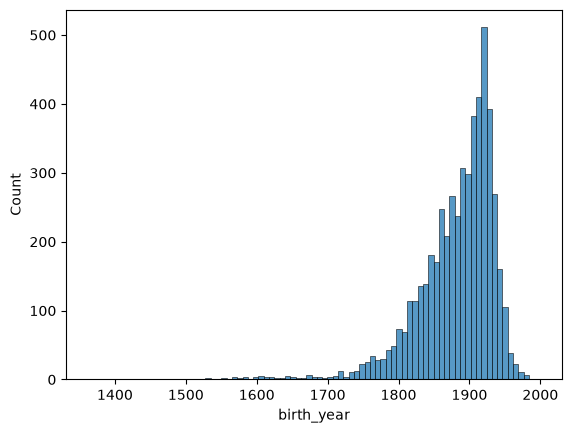

In [ ]:
import matplotlib.pyplot as plt         # plotting library (alternatives: ggplot)
import seaborn as sns                   # helper plotting library that combines matplotlib and pandas

sns.histplot(df["birth_year"])     # equivalent to `sns.histplot(data=df, x="birth_year")`

### Redesigning for Clarity

Choose a visual metaphor that *best represents your variables!*

For each variable, ask...
- How is it __*encoded*__ (example: is `birth_year` an `int` or `str`)?
- Is it ordered? (if not, it is __*categorical*__ or __*nominal*__)
- Is its size or scale meaningful? (if it has order but not scale, it is __*ordinal*__, if it has both it is __*numerical*__)
- Can it vary smoothly? (if not it is __*discrete*__, otherwise it is __*continuous*__)

<Axes: xlabel='first_name', ylabel='birth_year'>

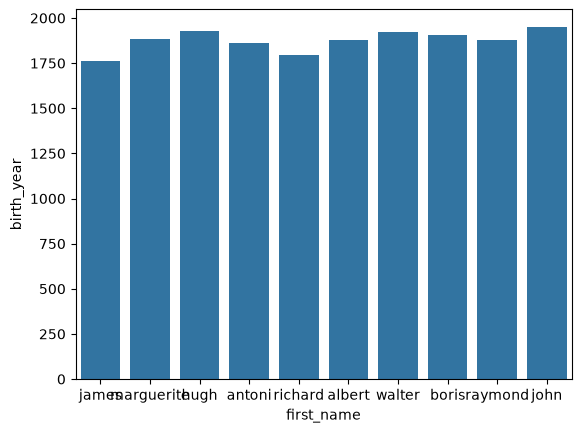

In [10]:
# why isn't this effective?
sns.barplot(data=df[:10], x="first_name", y="birth_year")

Choose a plot type that *minimizes distortion!*

<Axes: xlabel='birth_year'>

/home/devin/e/mila_mirror/proj/name-embedding/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


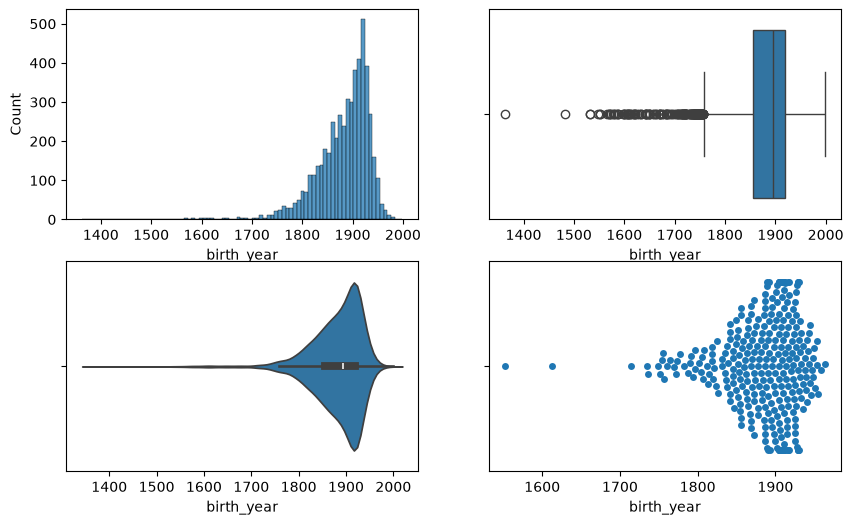

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6)) # create a 2x2 grid of subplots

# which one is most effective?
sns.histplot(x=df["birth_year"], ax=axes[0, 0])             # plots to subplot at row 0, col 0
sns.boxplot(x=df["birth_year"], ax=axes[0, 1])              # plots to subplot at row 0, col 1
sns.violinplot(x=df["birth_year"], ax=axes[1, 0])
sns.swarmplot(x=df["birth_year"][:300], ax=axes[1, 1])      # only plot the first 300 points for speed

## Multivariate Questions

*What are the **relationships** between variables?*

In [12]:
df["occupation"].unique()       # always look at the data first!

<ArrowStringArray>
[        'farmer',          'actor',         'priest',      'publisher',
       'engineer',       'novelist',       'composer',         'author',
      'executive',        'painter',         'writer',       'explorer',
       'merchant',           'poet',         'lawyer',      'historian',
    'broadcaster',         'artist',        'scholar',         'doctor',
      'professor',        'grazier',  'administrator',     'politician',
       'academic',      'physician',      'filmmaker',     'journalist',
       'director',        'officer', 'businessperson',       'inventor',
   'entrepreneur',        'soldier',       'diplomat',          'miner',
          'clerk',     'playwright',          'owner',        'teacher',
       'minister',       'official',       'educator',         'cleric',
          'judge',   'photographer',     'missionary',  'industrialist',
      'economist',       'attorney',       'activist',         'worker',
        'manager',       'musici

What *questions* can we answer using `birth_year` and `occupation`?

<Axes: xlabel='birth_year', ylabel='occupation'>

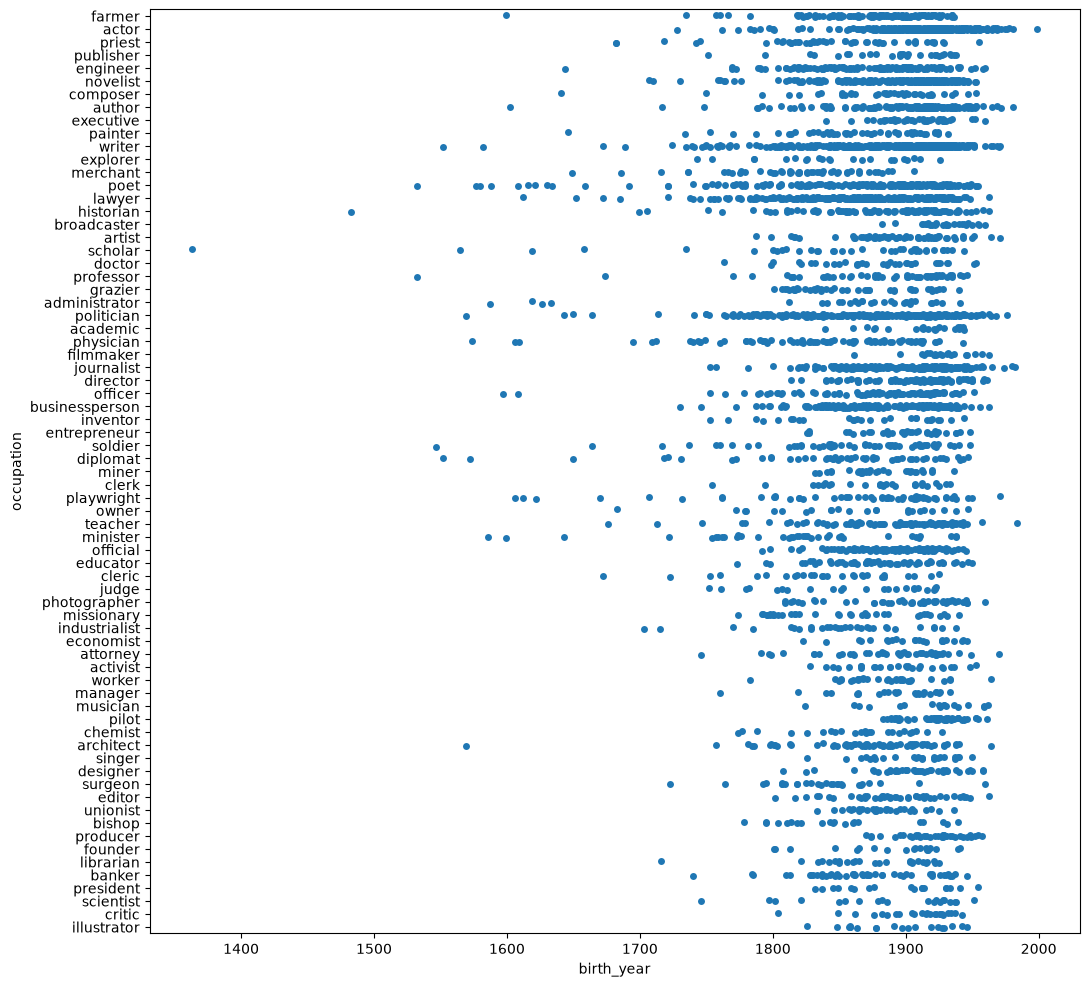

In [13]:
fig = plt.figure(figsize=(12, 12))                      # make the plot bigger
sns.stripplot(data=df, x="birth_year", y="occupation")  # plot birth_year vs occupation

### Redesigning for Clarity

Choose a visual metaphor that *best matches your question!*

*Order* is meaningful, even for unordered variables!

<Axes: xlabel='birth_year', ylabel='occupation'>

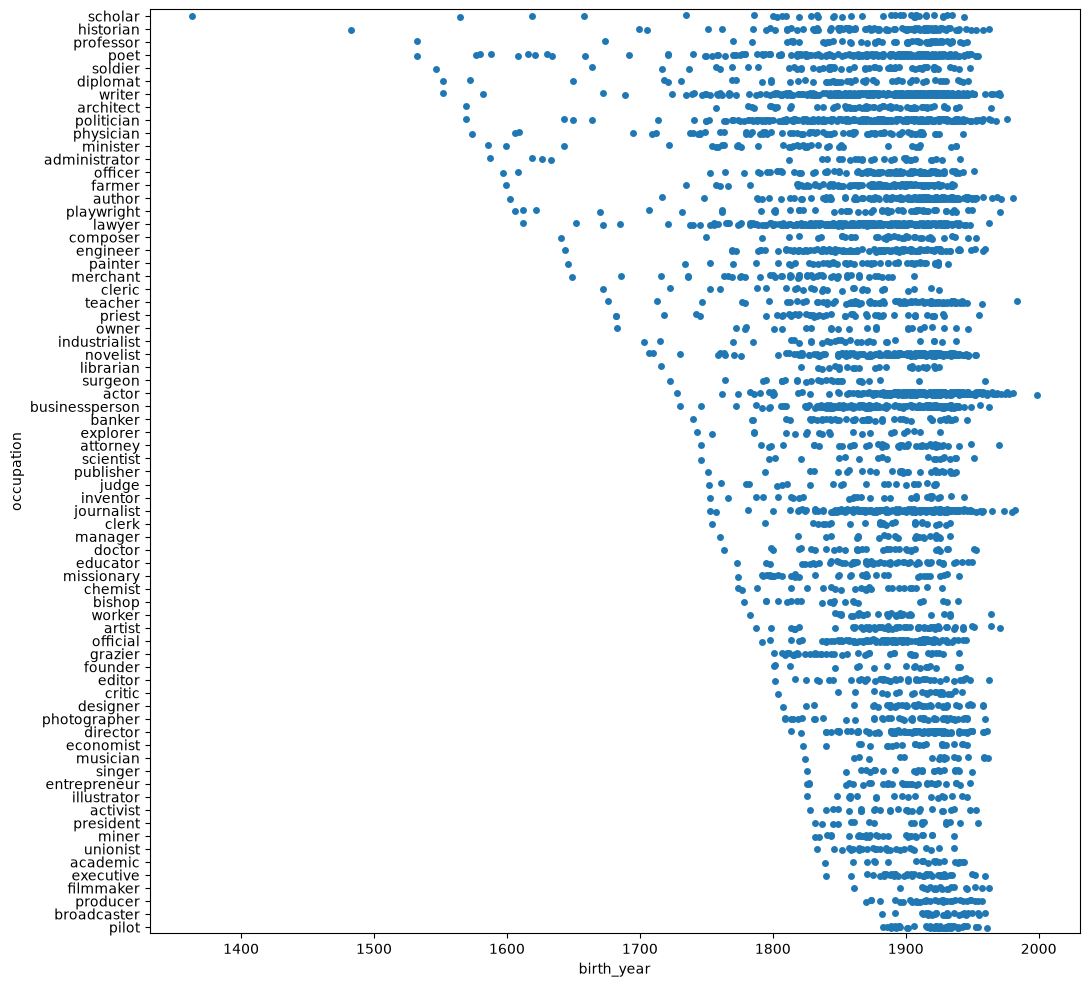

In [14]:
sort_by_birth_df = df.sort_values("birth_year")     # sort dataframe by the column `birth_year`

fig = plt.figure(figsize=(12, 12))
sns.stripplot(data=sort_by_birth_df, x="birth_year", y="occupation")

Only plot what is necessary for the question, or in other words
> *maximize data-ink ratio* (Tufte, *The Visual Display of Quantitative Information*).

In [ ]:
# helper function to transform dataframe into the row with the minimum birth_year
def get_min_birth_year(df):
    min_year_row_idx = np.argmin(df["birth_year"])
    return df.iloc[min_year_row_idx]


occupation_groups = df.groupby("occupation")                # split dataframe by occupation

occupation_df = occupation_groups.apply(get_min_birth_year) # apply transform to each group

# `if` is needed as different versions of pandas may or may not keep the groupby column
if "occupation" not in occupation_df.columns:               # make `occupation` a column again
    occupation_df = occupation_df.reset_index()
# note: previous lines are equivalent (with the exception of the index) to
"""
rows = []
for occupation, sub_df in occupation_groups:
    rows.append(get_min_birth_year(sub_df))
occupation_df = pd.DataFrame(rows)
"""

occupation_df = occupation_df.sort_values("birth_year")

print(len(occupation_df))                                   # look at the data again
occupation_df.head()                                        # check that the transforms worked

71


,occupation,title,first_name,nationality,birth_year,age,article,url
62,scholar,jean gerson,jean,French,1363,65,jean charlier de gerson ( 13 december 1363 -- ...,https://en.wikipedia.org/wiki/index.php?curid=...
32,historian,francesco guicciardini,francesco,Italian,1483,57,francesco guicciardini (; 6 march 1483 -- 22 m...,https://en.wikipedia.org/wiki/index.php?curid=...
60,professor,wilhelm xylander,wilhelm,German,1532,43,"wilhelm xylander ( born wilhelm holtzman, grae...",https://en.wikipedia.org/wiki/index.php?curid=...
55,poet,ludwig helmbold,ludwig,German,1532,66,"ludwig helmbold, also spelled ludwig heimbold,...",https://en.wikipedia.org/wiki/index.php?curid=...
65,soldier,miguel de cervantes,miguel,Spanish,1547,68,miguel de cervantes saavedra ( or;; 29 septemb...,https://en.wikipedia.org/wiki/index.php?curid=...


<Axes: xlabel='birth_year', ylabel='occupation'>

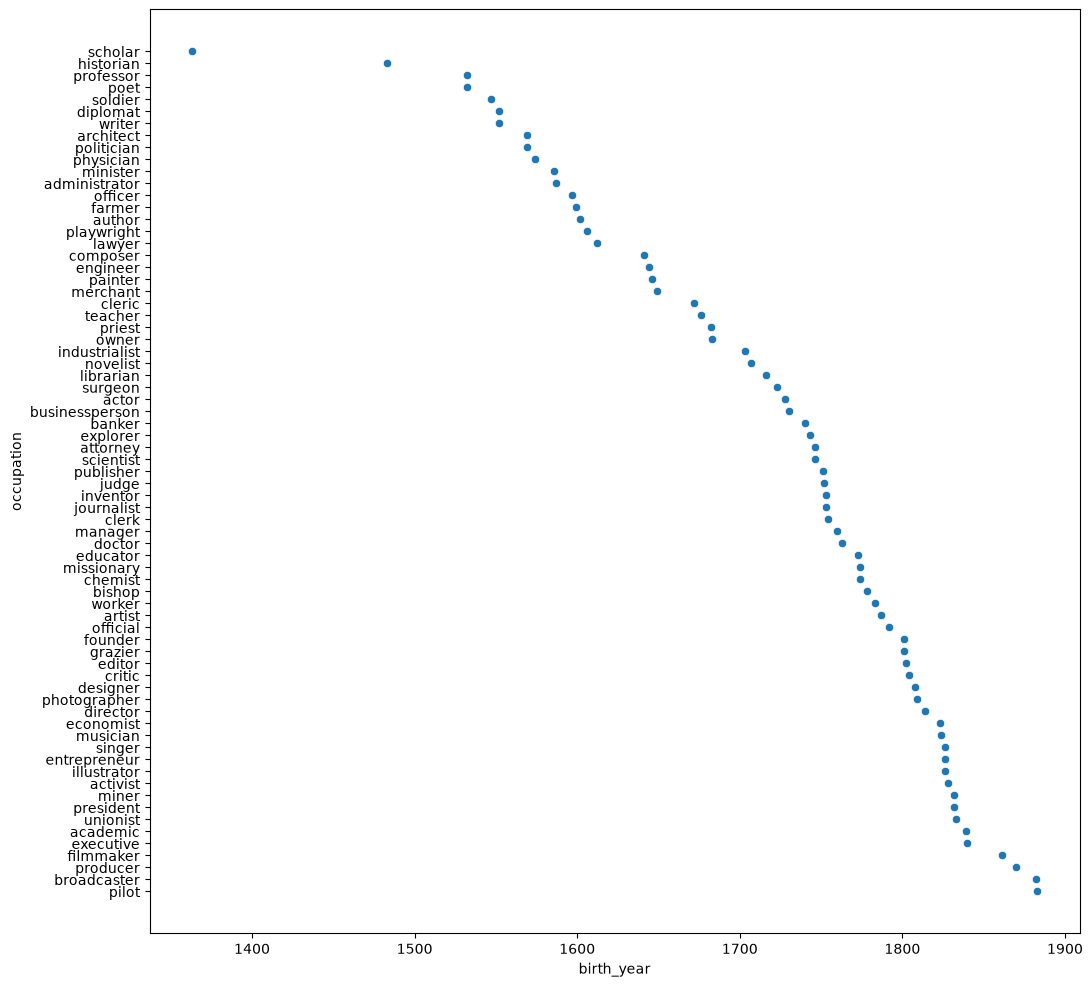

In [15]:
fig = plt.figure(figsize=(12, 12))
sns.scatterplot(data=occupation_df, x="birth_year", y="occupation")

__*Text*__ is also visualization!

In [16]:
"""Text scatterplot PROMPT:
Write a function with the same signature as seaborn's sns.scatterplot function that places text instead of markers. Text is passed as an argument `text: list[str] = None`. Text should be rendered with color and size appropriate to the original scatterplot function's markers.
"""

from functools import wraps
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


@wraps(sns.scatterplot)
def text_scatterplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    size=None,
    style=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    sizes=None,
    size_order=None,
    size_norm=None,
    markers=True,
    style_order=None,
    legend="auto",
    ax=None,
    text: list[str] = None,
    **kwargs,
):
    if text is None:
        raise ValueError("The 'text' argument is required.")

    # Allow passing either a list of strings, or a column name from 'data'
    if isinstance(text, str) and data is not None and text in data:
        text_labels = list(data[text])
    else:
        text_labels = list(text)

    if ax is None:
        ax = plt.gca()

    # 1. Let Seaborn render the plot to calculate all mapped aesthetics
    ax = sns.scatterplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        size=size,
        style=style,
        palette=palette,
        hue_order=hue_order,
        hue_norm=hue_norm,
        sizes=sizes,
        size_order=size_order,
        size_norm=size_norm,
        markers=markers,
        style_order=style_order,
        legend=legend,
        ax=ax,
        **kwargs,
    )

    # 2. Intercept the rendered PathCollection
    collection = ax.collections[-1]
    offsets = collection.get_offsets()
    colors = collection.get_facecolors()
    marker_areas = collection.get_sizes()

    if len(offsets) != len(text_labels):
        raise ValueError(
            f"Point count ({len(offsets)}) does not match text count ({len(text_labels)}). "
            "Ensure your x/y/hue/size data contains no NaN values."
        )

    # Remove the standard dots from the canvas
    collection.remove()

    # Broadcast mapped properties to match the array length
    if len(colors) == 1:
        colors = np.repeat(colors, len(offsets), axis=0)
    if len(marker_areas) == 1:
        marker_areas = np.repeat(marker_areas, len(offsets))

    # Geometric conversion: circle diameter = 2 * sqrt(Area / π)
    # (Multiplied by a 1.25 visual padding factor to balance typographic whitespace)
    font_sizes = (2 * np.sqrt(marker_areas / np.pi)) * 1.25

    # 3. Render the text
    for (x_pos, y_pos), txt, color, f_size in zip(
        offsets, text_labels, colors, font_sizes
    ):
        ax.text(
            x_pos,
            y_pos,
            str(txt),
            color=color,
            fontsize=f_size,
            ha="center",
            va="center",
        )

    return ax

[]

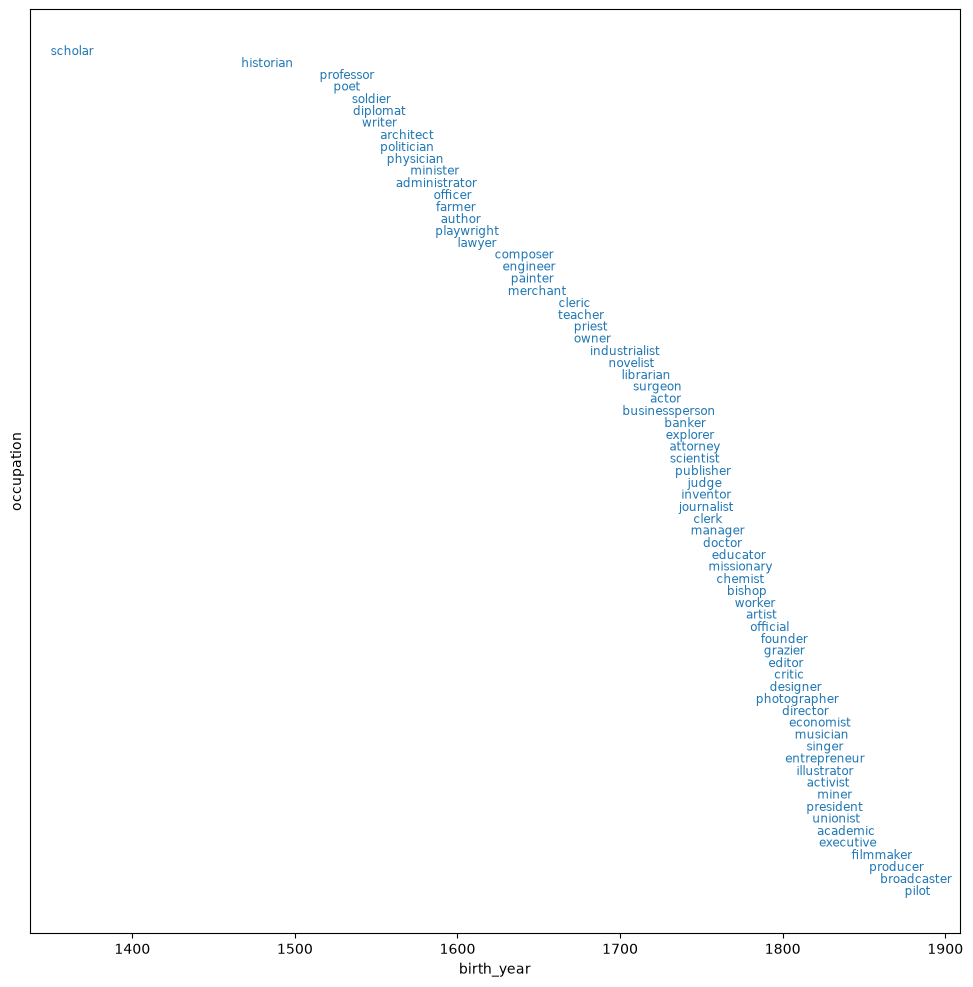

In [17]:
fig = plt.figure(figsize=(12, 12))

occupations = occupation_df["occupation"]   # text to replace scatterplot markers with
ax = text_scatterplot(data=occupation_df, x="birth_year", y="occupation", text=occupations)
ax.set_yticks([])                           # remove visual clutter from tick labels on y-axis

Visualization are not always the right tool!

In [18]:
# when is a table better?
table = occupation_df[["occupation", "birth_year"]].to_string(index=False)
print(table)

    occupation  birth_year
       scholar        1363
     historian        1483
     professor        1532
          poet        1532
       soldier        1547
      diplomat        1552
        writer        1552
     architect        1569
    politician        1569
     physician        1574
      minister        1586
 administrator        1587
       officer        1597
        farmer        1599
        author        1602
    playwright        1606
        lawyer        1612
      composer        1641
      engineer        1644
       painter        1646
      merchant        1649
        cleric        1672
       teacher        1676
        priest        1682
         owner        1683
 industrialist        1703
      novelist        1707
     librarian        1716
       surgeon        1723
         actor        1728
businessperson        1730
        banker        1740
      explorer        1743
      attorney        1746
     scientist        1746
     publisher        1751
 

### Aside: Summary Statistics

__*Summary statistics*__ turn distributions into single values.

* How many values are there? (__*counts*__, __*frequency*__ divides by total)
* What is the "typical" value? (__*mean*__ weights by size, __*median*__ is a type of percentile, __*mode*__ indicates highest count)
* How spread out are the values? (__*standard deviation*__ is a "typical" spread, top/bottom __*quartiles*__ are 25% and 75% percentiles, __*max*__ or __*min*__ are 0% and 100% percentiles)

<Axes: xlabel='birth_year', ylabel='occupation'>

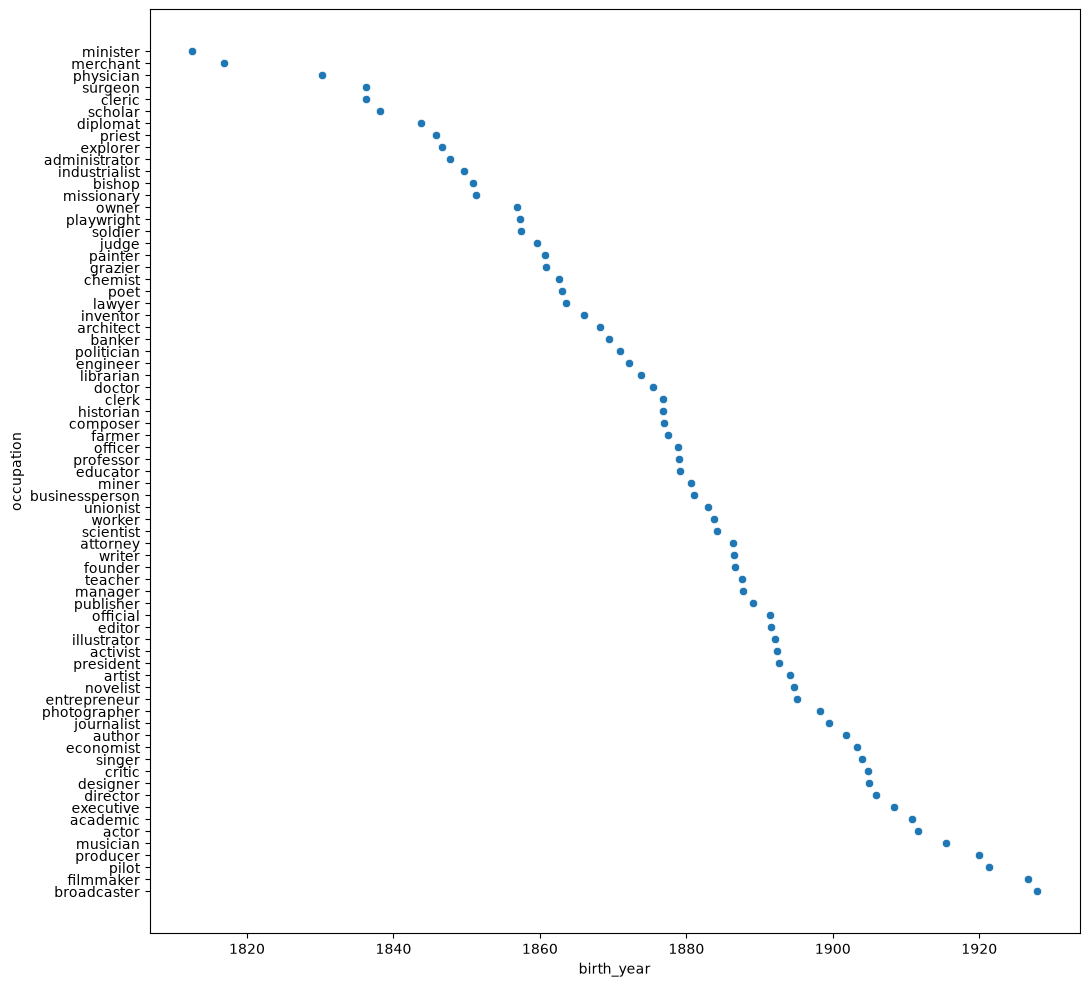

In [19]:
# what is the advantage of taking the mean instead of the min?
def get_mean_birth_year(df):
    mean_birth_year = np.mean(df["birth_year"])
    return mean_birth_year


sub_df = df[["birth_year", "occupation"]]                       # only need these 2 columns
occupation_groups = sub_df.groupby("occupation")

mean_birth_df = occupation_groups.apply(get_mean_birth_year)    # returns a series, not a dataframe
mean_birth_df = mean_birth_df.reset_index()                     # get occupation column back
mean_birth_df.columns = ["occupation", "birth_year"]            # column names were lost in the series

mean_birth_df = mean_birth_df.sort_values("birth_year")

fig = plt.figure(figsize=(12, 12))
sns.scatterplot(data=mean_birth_df, x="birth_year", y="occupation", ax=plt.gca())

### Aside: Correlation

For pairs of numeric variables, ask: *are they **correlated** (linearly related)?*

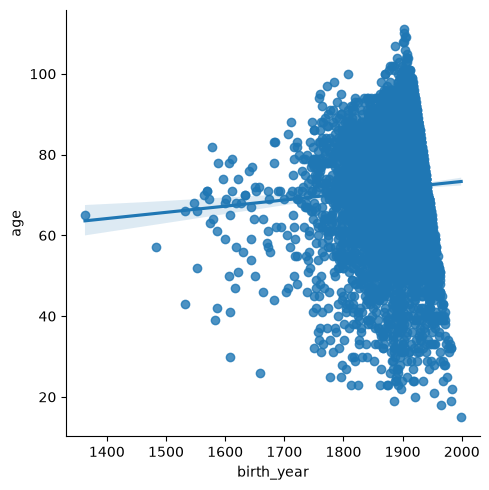

In [20]:
sns.lmplot(data=df, x="birth_year", y="age")    # linear regression predicts age from birth_year

## Document Embeddings

*Can we create variables from **unstructured** data?*

In [21]:
# code to generate text embeddings from a small model
"""Text embedding model research PROMPT:
What is the best text embedding model that is also fairly small for generating vectors for short articles (~1 paragraph of about ~8 sentences). Must be available via huggingface libraries (hf hub and transformers) for easy download and local inference.
"""

# I chose BAAI/bge-small-en-v1.5 from the answers
"""Text embedding PROMPT:
Write python code to do the following:
- function to prepare `BAAI/bge-small-en-v1.5` from hugging face (download and initialize the objects for inference, passing to CUDA, etc.)
- functioin that uses the prepared HF model to generate embeddings, takes a list of strings as input and batch size, returns a list of embeddings of fixed size per string.
"""
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

def prepare_bge_model():
    """Downloads and initializes the BAAI/bge-small-en-v1.5 model and tokenizer."""
    model_name = "BAAI/bge-small-en-v1.5"
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    
    # Move to CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    return tokenizer, model, device

def generate_embeddings(texts, tokenizer, model, device, batch_size=8):
    """Generates L2-normalized CLS embeddings for a list of strings in batches."""
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i + batch_size]
        
        encoded_input = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=512,
            return_tensors='pt'
        ).to(device)
        
        with torch.no_grad():
            model_output = model(**encoded_input)
            # BGE models use the CLS token (first token) for sequence representations
            batch_embeddings = model_output[0][:, 0]
            # Normalization is required for BGE models for cosine similarity
            batch_embeddings = torch.nn.functional.normalize(batch_embeddings, p=2, dim=1)
            
        all_embeddings.extend(batch_embeddings.cpu().numpy())
        
    return np.stack(all_embeddings, axis=0)

/home/devin/e/mila_mirror/proj/name-embedding/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# turn articles into embedding vectors
tokenizer, model, device = prepare_bge_model()  # initialize the tokenizer and language model
# note: the tokenizer turns strings into vectors (torch.Tensor), as the model requires vector inputs

subset_df = df[:100]            # use a subset of articles only to speed up embedding and plotting
# include both name and occupation in scatterplot markers
text_labels = subset_df.apply(lambda row: f'{row["first_name"]} ({row["birth_year"]}) {row["occupation"]}', axis=1)


article_embeddings = generate_embeddings(subset_df["article"].tolist(), tokenizer, model, device)
article_embeddings.shape        # what do each of these dimensions mean?

100%|██████████| 13/13 [00:00<00:00, 33.39it/s]


(100, 384)

### Aside: Unsupervised Learning

We can use *unsupervised methods* to visualize embeddings (but beware of "reading tea leaves")!

/home/devin/e/mila_mirror/proj/name-embedding/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


<Axes: >

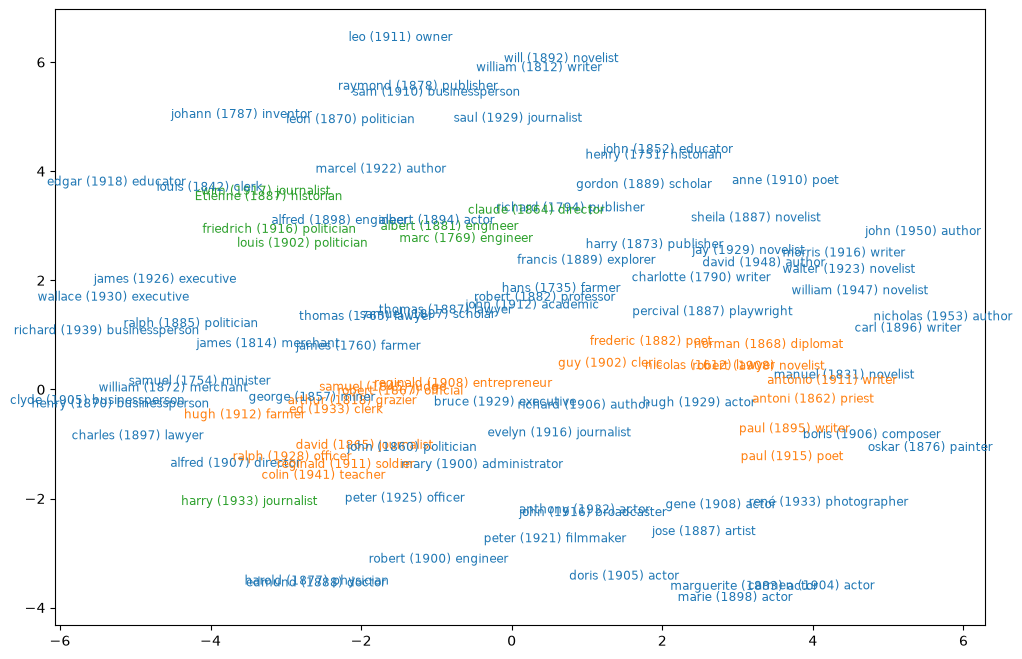

In [23]:
from sklearn.cluster import HDBSCAN                         # a clustering method
from sklearn.manifold import TSNE                           # non-linear dimensionality reduction method

# use clustering to identify similar articles
cluster_method = HDBSCAN(min_cluster_size=3)                # unsupervised clustering of articles
clusters = cluster_method.fit_predict(article_embeddings)   # find clusters and label each article
clusters = [str(x) for x in clusters]                       # convert int labels to strings for plotting

# use dimensionality reduction to plot high-dimensional vectors
visualizer = TSNE(n_components=2)                           # reduce to 2 dimensions for plotting
embed_2d = visualizer.fit_transform(article_embeddings)     # transform 384-dimensional embeddings into 2D
embed_x = embed_2d[:, 0]                                    # indexes all articles and dimension 0
embed_y = embed_2d[:, 1]                                    # indexes all articles and dimension 1

fig = plt.figure(figsize=(12, 8))
text_scatterplot(x=embed_x, y=embed_y, hue=clusters, text=text_labels, legend=None)  # remove the legend as clusters don't have meaningful names

### Vector Similarity Search

We can find and compare articles by embedding text queries!

In [24]:
# embed queries to compare articles against
query_texts = ["criminal", "creative"]
query_embeddings = generate_embeddings(query_texts, tokenizer, model, device)
query_embeddings.shape

100%|██████████| 1/1 [00:00<00:00, 39.18it/s]


(2, 384)

In [25]:
# do vector similarity search
from sklearn.metrics.pairwise import cosine_similarity  # measures angle between two vectors

# cosine similarity ranges from -1 to 1, where 1 is most similar
similarity = cosine_similarity(article_embeddings, query_embeddings)
similarity.shape                                        # shape is (articles, references)

(100, 2)

<Axes: >

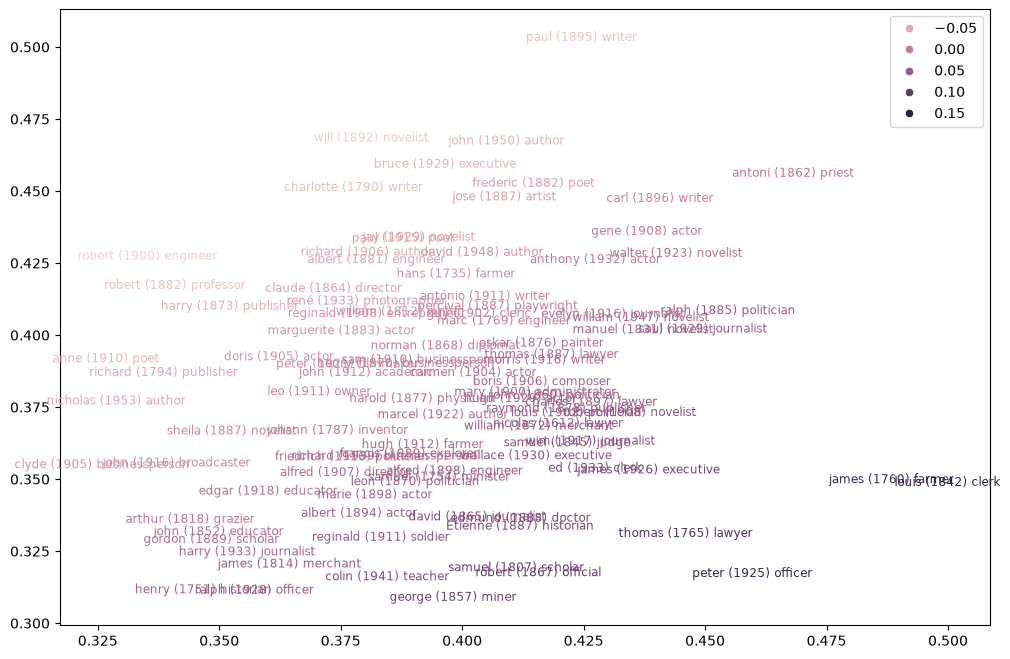

In [26]:
# plot biographies along "criminal" and "creative" dimensions
similarity_x = similarity[:, 0]             # indexes all articles and reference 0, "criminal"
similarity_y = similarity[:, 1]             # indexes all articles and reference 1, "creative"

score = similarity[:, 0] - similarity[:, 1] # difference between "criminal" and "creative" similarities

fig = plt.figure(figsize=(12, 8))
text_scatterplot(x=similarity_x, y=similarity_y, hue=score, text=text_labels)

### Aside: Cosine Similarity

We usually compare embedding vectors using __*cosine similarity*__.

The __*cosine similarity*__ between two $n$-dimensional vectors $\bf{x}$ and $\bf{y}$ is computed as:
\begin{align*}
    Sim(\bf{x}, \bf{y}) = \frac{\bf{x} \cdot \bf{y}}{\|\bf{x}\| \|\bf{y}\|}
\end{align*}

where the length (Euclidean distance, or norm) of a vector given by $\| \bf{x} \|$ is:
\begin{align*}
    \|\bf{x}\| = \sqrt{\bf{x} \cdot \bf{x}}
\end{align*}

and the dot product between vectors is:
\begin{align*}
    \bf{x} \cdot \bf{y} = \sum_{i=1}^n x_i y_i
\end{align*}

Note: we can use any distance measure (e.g. Euclidean distance) to compare embedding vectors.

### Aside: Detecting Outliers and Errors

We can compare different parts of our text data to identify discrepancies.

100%|██████████| 13/13 [00:00<00:00, 136.72it/s]


<Axes: >

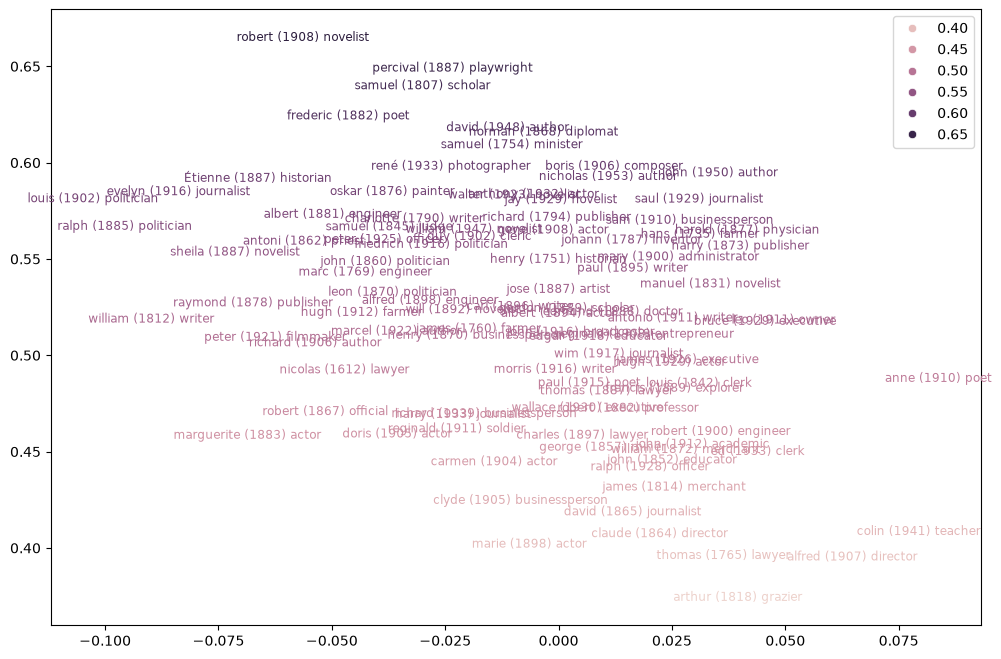

In [30]:
from sklearn.linear_model import Ridge      # regularized linear regression

# embed the occupation labels
occupation_embeddings = generate_embeddings(subset_df["occupation"].tolist(), tokenizer, model, device)
# calculate similarity between each article and its occupation label
similarity_matrix = cosine_similarity(occupation_embeddings, article_embeddings)    # n x n similarities between all articles and occupations
# we only want the similarity of an article with its own occupation
occupation_to_article_similarity = np.diag(similarity_matrix)           # `np.diag` returns the n diagonal entries of the matrix

# (optional) fit a linear regression to find the best embedding dimension to plot
dim_reducer = Ridge()
dim_reducer.fit(article_embeddings, occupation_to_article_similarity)   # try to predict how similar each article is to its occupation
top_coefficients = np.argsort(np.abs(dim_reducer.coef_))                # `coef_` are fitted weights for each embedding dimension
sorted_embeddings = article_embeddings[:, top_coefficients]             # sort embedding dimensions by absolute magnitude of their coefficients
top_embedding_dim = sorted_embeddings[:, -1]                            # index all articles and biggest (last) dimension, index last dimension with -1

fig = plt.figure(figsize=(12, 8))
# the bottommost part of the y-axis contains articles that most disagree with their occupation labels
text_scatterplot(x=top_embedding_dim, y=occupation_to_article_similarity, hue=occupation_to_article_similarity, text=text_labels)

In [ ]:
# get the articles that are least similar to their occupations
top_3_most_disagreeing = np.argsort(occupation_to_article_similarity)[:3]   # index first 3 articles (smallest cosine similarity)

# manually check that we have found outliers or mistakes in occupation labels
for _, row in subset_df.iloc[top_3_most_disagreeing].iterrows():
    print(row["occupation"], row["article"], sep="\t")

grazier	`` for the australian rules footballer, see arthur hodgson ( footballer ). '' sir arthur hodgson kcmg ( 29 june 1818 -- 24 december 1902 ) was an australian pioneer and politician.
director	alfred ashley-brown ( 6 november 1907 -- 5 march 1993 ) was an australian politician. born in sydney, he was a company director, and served in the military 1942-45 - rank of major. a member of blacktown city council, he was the mayor from 1961 -- 65 and 1968-71. in 1972, he was elected to the australian house of representatives as the labor member for mitchell, defeating liberal mp les irwin. he was defeated by liberal alan cadman in 1974. ashley-brown died in 1993.
lawyer	thomas muir ( 24 august 1765 -- 26 january 1799 ), often known as thomas muir the younger of huntershill, was a scottish political reformer.
